# MULTI-ANGLE TWO STEP CLASSIFICATION

## Explications générales : 

Ce script est la version améliorée de MULTI_ANGLE_FINAL_SAUVEGARDE (qui est la version qui est décrite dans les lignes suivantes et qui correspond à MULTI_ANGLE_FINAL_SAUVEGARDE)
Ce script fait suite logique à MULTI_CAM_COMBI

Dans le prolongement de la réflexion sur MULTI_CAM_COMBI, il a été décidé qu'il serait intéressant de construire un modèle à "deux étages" profitant de la présénce de trois caméras pour les combiner et donc d'agencer trois "angles". 

Le principe est le suivant : On considère donc 3 angles, donc 3 duos (102/103, 102/104 et 103/104) et on construit aussi 3 "modèles" MoViNet chacun propre à un duo spécifique. On fait alors passer chacun des duos dans son modèle (individuellement cela revient à faire tourner MULTI_CAM_PURE) et on récupère non pas la classification finale, mais le résultat de la couche précédente, située juste avant, un vecteur avec toutes les "caractéristiques" intéressantes déduites par le modèle, ce vecteur s'appelle "l'embedding".

On concatène alors chacun des embeddings, que l'on donne ensuite à un modèle final, qui nous donnera alors la classification binaire finale.

On possède alors 3 "sous-modèle", un pour chaque duo, et un modèle final pour concaténer tout les angles et déduire les relations entre ces derniers pour prendre la décision finale.

Simple aparté : On notera alors ici, l'importance de bien ordonner les vecteurs des features et labels des listes train et test, sans quoi la concaténation des "embeddings" n'aurait pas de sens. C'est à dire, il faut s'assurer que la vidéo d'une action soit bien la même chez les autres duos lors de la concaténation et pareil pour les vidéos négatives etc...

Des modifications ont ainsi été apportées à la manière de construire le jeu de données et la partie permettant la création et le lancement des modèles, le début reste, dès lors, fondamentalement la même chose que pour MULTI_CAM_PURE mais avec quelques boucles for pour prendre en compte les différents angles. 

## Histoire de MULTI_ANGLE : (A LIRE)

Ce script a été écrit après la mésaventure décrite dans les explications générales de MULTI_ANGLE_KIREMARHCE. Ainsi après avoir retrouvé une version qui marchait avec des résultats potables, j'ai décidé non pas de rebidouiller ce même code mais au final de repartir de "zéro". Je suis donc reparti entièrement d'une copie de MULTI_CAM_PURE, que j'ai alors modifiée pour en arriver au résultat escompté décrit plus haut. Ceci étant, j'ai décidé d'abandonner le fait de chercher pourquoi MULTI_ANGLE_KIREMARCHE n'a pas les mêmes performances que MULTI_CAM_PURE concernant l'ancien dataset (qui est le seul avec lequel on pouvait vraiment comparer les perfs, car avec le nouveau comme dans les deux cas (les deux codes) ont du mal à apprendre on ne voyait pas forcément de différence majeure qui ne pouvait pas être justifiée par la stochasticité de l'expérience). Enfin bref, ce code est maintenant le bon et celui à utiliser, il possède les mêmes perfs que MULTI_CAM_PURE concernant l'ancien dataset pour les 3 sous-modèles (ce qui est enfin logique) ce qui le rend très certainement plus fiable que MULTI_ANGLE_KIREMARCHE. Concernant le nouveau dataset, il ne montre pas encore à l'heure où je l'écris des résultats plus convaincants que MULTI_ANGLE_KIREMARCHE, les deux sont assez similaires tout compte fait. Cependant, je pense qu'il est plus sage d'utiliser celui-là, il est écrit plus naturellement et est donc plus simple à comprendre et à manipuler. De ce fait, il est peut-être possible qu'il prenne beaucoup de RAM à cause des temps de calculs (ce n'était plus dans mes priorités), à optimiser si besoin (ce qui devrait être largement améliorable je pense, surtout concernant l'extraction des features et des clips).

!!!!!!! Aussi ce script se doit de rester inchangé, il s'agit d'une version de sauvegarde afin que je puisse sans crainte modifier une copie (qui est donc ce script) pour en améliorer les performances. (VOIR MULTI_ANGLE_FINAL_SAUVEGARDE) ici c'est la version que j'ai décidé d'encore améliorer notament en dégelant le Backbone ce qui donne les meilleurs perfs à ce jour (attention dans ce cas précis dégeler le backbone n'est pas du fine-tuning de MoViNet)

## Notes concernant certains modules 

### Modules "movinet" et "movinet_model" 

movinet : Contient le backbone du modèle MoViNet. Le backbone est la partie principale du réseau de neurones qui lit les vidéos et encode chaque clip en un vecteur de caractéristiques (features). C’est ce backbone qui effectue réellement l’extraction des informations utiles
des vidéos, en résummant ce qu'a effectué le réseau de neurone en un vecteur de features. Ces features pourront ensuite être données à une tête de classification pour prendre une décision (passif/actif).

movinet_model : Permet de construire le modèle complet de MoViNet, incluant la tête de classification. La tête prend en entrée les features extraites par le backbone (module "movinet") et produit la prédiction finale (passif/actif). La tête possède ses propres neurones et poids, et elle peut être entraînée avec ou sans modifier les poids du backbone selon que ce dernier est gelé ou non.

### Modules de Keras

Dense : C’est une couche entièrement connectée, c'est à dire que chaque neurone de cette couche est connecté à tous les neurones de la couche précédente. Ici, elle est utilisée pour pendre le vecteur de features (issu du backbone MoViNet ou d’un GlobalAveragePooling3D) et calculer la prédiction finale : passif (0) ou actif (1). C’est donc la couche qui décide de la sortie du modèle. Cependant on peut en avoir plusieurs

Dropout : Sert à régulariser le modèle. Pendant l’entraînement, elle éteint aléatoirement certains neurones à chaque batch pour éviter que le modèle devienne trop adapté aux données d’entraînement (overfitting). Ici, elle est généralement utilisée entre Dense et Dense, pour éviter de trop dépendre de certains neurones.

GlobalAveragepooling3D : Prend les features volumineuses produites par le backbone MoViNet à partir d’un clip vidéo et fait la moyenne sur toutes les dimensions temporelles et spatiales (frames, hauteur, largeur), pour produire un vecteur compact qui résume l’information essentielle du clip. Afin de donner ce vecteur à la couche Dense de la tête de classification, qui prend la décision. Permet de réduire la taille des données et le temps de calcul et de rendre l’entrée compatible avec la couche de décision finale.

## Installation des modules et imports

Importation des modules nécéssaires



In [1]:
# Gestion des fichiers et chemins
import os 
# Permet de controler les print de TensorFlow : 0 = tout, 1 = info, 2 = warning, 3 = erreur
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  

# OpenCV, traitement vidéos
import cv2 

# Affichage et traitement d'images
import PIL 

# Permet de gérer les logs (en soit les "print", messages du programme)
import absl.logging 

# Permet de chercher et manipuler du texte (ici pour trier "video1_2" avant "video1_10" par ex)
import re 

# Permet de générer des nombres aléatoires
import random 

# Création de graphes
import matplotlib as mpl 
import matplotlib.pyplot as plt 
from IPython.display import Image, display

# Outils de calculs et traitements de données (tableaux, fonctions)
import math  
import numpy as np 
import pandas as pd 

# Gestion des dates et des temps, permet de convertir, comparer et manipuler les timestamps
from datetime import datetime, timedelta 

# Permet d'afficher des barres de progression lors de boucles longues
from tqdm import tqdm 

# Permet d'afficher la capacité de la ram dispo
import psutil 
print(f"RAM totale disponible : {psutil.virtual_memory().total / (1024**3):.2f} Go") 

# Permet de gérer les logs (prints)
import logging 

# Bibliothèque (outils) principale pour créer, entraîner et exécuter des modèles d'IA
import tensorflow as tf 
# Permet d'arrêter de print les warnings (causé par mon environnement tf12 cf explications MULTI_CAM_KIREMARCHE), pas forcément utile, dépend de l'ordi, à mettre direct après import tensorflow
tf.get_logger().setLevel(logging.ERROR) 

# Permet de télécharger les jeux de données déjà prêts de TensorFlow
import tensorflow_datasets as tfds 
# Permet de charger des modèles pré-entraînés de TensorFlow (ici : MoViNet)
import tensorflow_hub as hub
# Contient le backbone du modèle MoViNet et produit un vecteur de features
from official.projects.movinet.modeling import movinet 
# Permet,à partir du vecteur de features produit par le module movinet, de prendre un décision et d'ajuster le modèle
from official.projects.movinet.modeling import movinet_model 
# Permet de construire un modèle de réseau de neurones "à la main" (utlisé non pas pour le backbone mais pour movinet_model = dernière couche)
from tensorflow.keras.models import Sequential 
# Outils pour la construction de neurone
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling3D, Input, Concatenate 
# Outil pour séparer les données en ensembles d'entraînement et de te
from sklearn.model_selection import train_test_split
# Outil pour créer des matrices de confusion
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_recall_curve

# Active le "Just-In-Time Compilation" de TensorFlow, permet d'exécuter plus rapidement certains calculs sans perte de performances
tf.config.optimizer.set_jit(True) 

RAM totale disponible : 13.65 Go


/home/amerzone/miniconda3/envs/ia_movinet_tf12/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/home/amerzone/miniconda3/envs/ia_movinet_tf12/lib/python3.10/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
/home/amerzone/miniconda3/envs/ia_movinet_tf12/lib/python3.10/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

Tens

## Préparation du set de données et génération des clips

Paramètres de lancement :

In [ ]:
# Répertoire des données, contenant les différentes sessions avec les vidéos
VIDEO_ROOT = "/home/amerzone/kth/VIDEOS_NEW" 

# Modèle de MoViNet que l'on veut utiliser
MOVINET = 5 

# Nombre de frames extraites pour chaque clip vidéo, c'est-à-dire la longueur d'un clip
CLIP_LENGTH = 25

# Résolution des vidéos
VIDEO_SIZE = (200,200) 

# Nombre de clips traités simultanément pendant l'entrainement de l'IA
BATCH_SIZE = 3  

# Nombre de clips traités simultanément pendant l'extraction des features (à ajuster en fonction du processeur)
BATCH_SIZE_FEATS = 4  

# Ratio de vidéo négatives que l'on souhaite rajouter
NEG_RATIO = 1 

# Nombre d'epochs pour les 3 sous-modèles
EPOCHS = 200

# Nombre d'epochs pour le modèle finale
EPOCHS_FINAL = 100

# Pour savoir si pour l'extraction du clip, la frame donnée est centrale ou décalé vers la gauche (c'est à dire on prend un peu plus de ce qui se passe après le tag)
DECALE = True 

# Pour savoir si on veut que l'aléatoire soit pareil entre différents tests, mieux vaut rester en True
SAME_RANDOM = True 

# Fixation pour aléatoire, il est préférable de ne pas trop jouer avec, pas à trop modifier donc
RANDOM_PARAM = 38 

# Permet ou non d'autoriser l'entrainement du backbone (=! Fine-tuning) (en réalité sert pour BatchNorm ce qui n'est pas du deeper-layering)
BACKBONE = True

Paramètres à ne pas modifier :

In [3]:
# Format du temps utilisé
TIME_FORMAT = "%Y-%m-%d-%H-%M-%S-%f" 

# Duos de toutes les caméras disponibles
CAMERA = [["192.168.1.102","192.168.1.103"],["192.168.1.102","192.168.1.104"],["192.168.1.103","192.168.1.104"]] 

# Liste de toutes les caméras
ALL_CAM= ["192.168.1.102","192.168.1.103","192.168.1.104"]

# Format utilisé par Keras (pour les inputs des modèles)
CAMERA_KERAS = [[ip.replace(".", "_") for ip in CAMERA[0]],[ip.replace(".", "_") for ip in CAMERA[1]],[ip.replace(".", "_") for ip in CAMERA[2]]] 

# 0.5s de tolérance entre l'horodatage des vidéos et la ligne correspondante dans le fichier .txt
LABEL_TOLERANCE_SECONDS = 0.5  

# Classification binaire donc 1
NUM_CLASSES = 1  

print(CAMERA_KERAS)

if SAME_RANDOM == True :
    np.random.seed(RANDOM_PARAM)
    random.seed(RANDOM_PARAM)
    tf.random.set_seed(RANDOM_PARAM)

[['192_168_1_102', '192_168_1_103'], ['192_168_1_102', '192_168_1_104'], ['192_168_1_103', '192_168_1_104']]


Fonctions de tri des vidéos

In [4]:
def parse_info_txt(info_path):
    """
    Lit info.txt et retourne une liste de tuples : [(datetime, frame, label)]
    """
    info_data = []
    with open(info_path, 'r') as f:
        for line in f:
            parts = line.strip().split(';')
            if len(parts) != 3:
                print(f"[WARNING] Incorrect size, line ignored : '{line.strip()}'")
                continue
            timestamp_str, frame_str, label_str = parts
            try:
                timestamp = datetime.strptime(timestamp_str.strip(), TIME_FORMAT)
                frame = int(frame_str.strip())
                label = int(label_str.strip())
                info_data.append((timestamp, frame, label))
            except Exception as e:
                print(e)
                continue
    return info_data


def natural_sort_key(s): # N'est plus utilisée mais peut être utile
    """
    Crée une clé pour trier les fichiers de manière "naturelle" : séparer les nombres du texte dans le nom du fichier
    ex : 'video1_10.mp4' devient ['video', 1, '_', 10, '.mp', 4].
    Ensuite, chaque élément de la liste est comparé un par un lors du tri :
    - les parties numériques sont comparées comme des nombres (int)
    - les parties textuelles sont comparées en minuscules (insensible à la casse)
    """
    return [int(text) if text.isdigit() else text.lower() for text in re.split(r'(\d+)', s)]


def get_name_nb(camera_path,video_name, frame_number, index, session_num, Dossier):
    """
    Retourne le nom de la video, ainsi que le numéro de frame associé (intrinsèquement à la vidéo), correspondant au numéro de frame taggé
    Parcours alors toutes les vidéos d'une même "prise" dans un dossier caméra
    ex: à partir de video1_1.mp4, ou encore à partir de video2_1.mp4 selon la "prise" (1 ou 2 ici)
    """
    try :
        video_path = os.path.join(camera_path,video_name)
        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if frame_number >= total_frames:
            index += 1
            return get_name_nb(camera_path,f"video{session_num}_{index}.mp4", frame_number-total_frames, index, session_num, Dossier)
        else :
            print(f"Session {int(Dossier.replace('Session_',''))}, Camera {os.path.basename(camera_path).split('.')[-1]}, video{session_num}_{index}.mp4, frame intrinsèque : {frame_number}")
            return (frame_number,f"video{session_num}_{index}.mp4")
    except Exception as e :
        print(f"[ERROR] Impossible to open the video : {video_path} , error : {e}")


def get_multi_cam_positive_events(root_dir):
    """
    Référence tout les tags/événements positifs, pour chaque tag :
    un dictionnaire est crée contenant le nom de session, les vidéos tagés avec leur numero de frame intrinsèque
    ex : { "id": "<session>_<take_index>", "session": "<nom de la session>", "cams": { "<ip_cam>": (chemin_video, frame_intrinsèque), ... }
    La fonction ne garde que les tags pour lesquels toutes les caméras de la liste CAMERA ont des vidéos
    """
    events = []
    for session in sorted(os.listdir(root_dir)):
        info_path = os.path.join(root_dir, session, "info.txt")
        if not os.path.isfile(info_path):
            print("[WARNING] info.txt not found")
            continue
        info_data = parse_info_txt(info_path)
        if not info_data:
            print("[WARNING] Problem with parse_info_txt function")
            continue
        take_idx = 0 # Numero de "prise" (correspond au premier index dans un nom de vidéo en partant de la gauche bien entendu)
        for timestamp, frame, label in info_data:
            if frame == 0:
                take_idx += 1
            if label != 1:
                continue
            cams_found = {}
            missing = False
            for cam_ip in ALL_CAM:
                camera_path = os.path.join(root_dir, session, cam_ip)
                name_start = f"video{take_idx}_1.mp4"
                if not os.path.isdir(camera_path):
                    print(f"[WARNING] Camera's folder missing : {camera_path}")
                    missing = True
                    break
                try:
                    frame_final, name = get_name_nb(camera_path, name_start, frame, 1, take_idx, session)
                    cams_found[cam_ip] = (os.path.join(camera_path, name), frame_final)
                except Exception as e:
                    print(f"[ERROR] {e}")
                    missing = True
                    break
            if missing:
                print(f"[WARNING] Skip an event because of a missing folder")
                continue
            events.append({
                "id": f"{session}_T{take_idx}",
                "session": session,
                "cams": cams_found
            })
    return events

Recherche de tous les tags/événements positifs et de leurs vidéos et frames associées

In [5]:
all_positive_videos = get_multi_cam_positive_events(VIDEO_ROOT)
print(f"\nall_positive_videos :{all_positive_videos}")
print(f"\nNombre d'événement positif : {len(all_positive_videos)}")

positive_video_paths = []
for event in all_positive_videos:
    for cam_ip, (path, frame) in event['cams'].items():
        positive_video_paths.append(path)
print("Nombre de vidéos positives :", len(positive_video_paths))

Session 10, Camera 102, video2_1.mp4, frame intrinsèque : 376
Session 10, Camera 103, video2_1.mp4, frame intrinsèque : 376
Session 10, Camera 104, video2_1.mp4, frame intrinsèque : 376
Session 10, Camera 102, video3_1.mp4, frame intrinsèque : 320
Session 10, Camera 103, video3_1.mp4, frame intrinsèque : 320
Session 10, Camera 104, video3_1.mp4, frame intrinsèque : 320
Session 10, Camera 102, video4_1.mp4, frame intrinsèque : 389
Session 10, Camera 103, video4_1.mp4, frame intrinsèque : 389
Session 10, Camera 104, video4_1.mp4, frame intrinsèque : 389
Session 10, Camera 102, video5_1.mp4, frame intrinsèque : 343
Session 10, Camera 103, video5_1.mp4, frame intrinsèque : 343
Session 10, Camera 104, video5_1.mp4, frame intrinsèque : 343
Session 10, Camera 102, video6_1.mp4, frame intrinsèque : 292
Session 10, Camera 103, video6_1.mp4, frame intrinsèque : 292
Session 10, Camera 104, video6_1.mp4, frame intrinsèque : 292
Session 10, Camera 102, video7_1.mp4, frame intrinsèque : 277
Session 

Séparation en deux jeux de données : entrainement et test

In [6]:
if SAME_RANDOM == True :
  train_pairs, test_pairs = train_test_split(all_positive_videos, test_size=0.2, random_state=RANDOM_PARAM )
  print(f"[INFORMATION] The repartition is control random with {RANDOM_PARAM} as start point")
else :
  train_pairs, test_pairs = train_test_split(all_positive_videos, test_size=0.2)
  print("[INFORMATION] The repartition is truly random")

print(f"\nNumber of positive events in train_pairs =", len(train_pairs))
print(f"Number of positive events in test_pairs =", len(test_pairs))

[INFORMATION] The repartition is control random with 38 as start point

Number of positive events in train_pairs = 49
Number of positive events in test_pairs = 13


Recherche des vidéos passives et bref résumé

NB : la liste positive_video_paths contient de par la manière dont elle a été construite tout les chemins des vidéos postives y compris les doublons, c'est à dire, si une vidéo contient deux tags, alors elle apparaitra deux fois dans la liste

In [7]:
def get_all_passive_videos(root_dir):
    """
    Retourne un tuple contentant la liste de tout les chemins des vidéos passives ainsi que du nombre total de vidéos (passives et actives comprises)
    """
    videos = []
    counter_all_videos = 0
    for session in sorted(os.listdir(root_dir)):
        for camera in ALL_CAM :
            camera_path = os.path.join(root_dir, session, camera)
            if not os.path.isdir(camera_path):
                continue
            for file in sorted(os.listdir(camera_path)):
                if file.endswith(".mp4") :
                    counter_all_videos += 1
                    if os.path.join(camera_path,file) not in positive_video_paths :
                        videos.append(os.path.join(camera_path, file))
    return (videos, counter_all_videos)

passive_videos, nb_all_videos = get_all_passive_videos(VIDEO_ROOT)
print("Little summary :")
print(f"Total number of videos = {nb_all_videos}")
print(f"Total number of active videos (without duplications) = {len(list(set(positive_video_paths)))}") # On passe positive_video_paths en "set" pour éliminer les doublons
print(f"Total number of passive videos = {len(passive_videos)}")

if nb_all_videos == (len(list(set(positive_video_paths)))+len(passive_videos)) :
  print("[COHERENCE] Everything is OK !")
else :
  print("[COHERENCE] Something is wrong !")

Little summary :
Total number of videos = 216
Total number of active videos (without duplications) = 186
Total number of passive videos = 30
[COHERENCE] Everything is OK !


Fonctions permettant de générer les données formater pour être données directement à l'IA

In [8]:
def extract_clip(video_path, center_frame):
    """
    Extrait un clip vidéo de longueur CLIP_LENGTH autour d'un frame central.
    Le clip consiste en un tableau numpy de forme (CLIP_LENGTH, H, W, 3) (avec les couleurs normalisées entre [0,1])
    et renvoit None si le clip ne peut pas être extrait (débordement, erreur de lecture…)
    """
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if DECALE == True :
        start = center_frame - CLIP_LENGTH // 4
    else : 
        start = center_frame - CLIP_LENGTH // 2
    end = start + CLIP_LENGTH

    if start < 0 or end > total_frames:
        return None

    clip = []
    cap.set(cv2.CAP_PROP_POS_FRAMES, start)

    for _ in range(CLIP_LENGTH):
        ret, frame = cap.read()
        if not ret: # ret est un booléen qui est True si la lecture de la vidéo est un succès
            return None
        frame = cv2.resize(frame, VIDEO_SIZE)
        clip.append(frame.astype(np.float32) / 255.0)

    cap.release()
    return np.array(clip)


def clip_generator_multi_cam(events_list, passive_videos, neg_ratio, duo, train, metafile):
    """
    Génère des clips synchronisés pour plusieurs caméras
    Elle parcourt une liste d'événements positifs (train_pairs/test_pairs) et génère :
    - les clips positifs à partir d'events_list
    - les clips négatifs pour compléter la base de données, à partir de vidéos passives, choisis aléatoirement,
      en s'assurant que toutes les caméras disposent de la vidéo et que
      le clip est extrait à la même frame pour chaque caméra.

    NB : Elle utilise un générateur avec "yield" ce qui permet d'appeler les clips un par un sans stocker tout en mémoire pour alléger le CPU
    Chaque "yield" renvoie un tuple (clips, label), concernant le clip cf extract_clip :
    """
    if train==True :
        random.seed(RANDOM_PARAM) # Ces deux lignes permettent d'avoir toujours les mêmes vidéos négatives
        np.random.seed(RANDOM_PARAM) # Donc avec celle là
    else : 
        random.seed(RANDOM_PARAM + 13) # le +13 c'est pour ne pas avoir les même vidéos négatives dans le set de test et celui d'entrainement
        np.random.seed(RANDOM_PARAM + 13) 
    for event in events_list:
        cams = event["cams"]
        clips_pos = []
        for cam_ip in duo: # On traite d'abord les clips postifs
            vpath, pos_frame = cams[cam_ip]
            clip = extract_clip(vpath, pos_frame)
            clips_pos.append(clip)
            #print(vpath,pos_frame)
        if all(c is not None for c in clips_pos):
            print(f"Positiv clips succesful : {len(clips_pos)}")
            if metafile == True :
                yield clips_pos, 1, {"type": "positive", "event_id": event["id"],"session": event["session"],"videos": {cam_ip: { "video": os.path.basename(vpath), "full_path": vpath, "frame": pos_frame}for cam_ip, (vpath, pos_frame) in cams.items()}}
            else : 
                yield clips_pos, 1, None

        success = 0  # Compteur de tentative réusite
        error = 0  # Compteur d'erreur
        while success < NEG_RATIO: # Puis les négatifs
            neg_video_path = passive_videos[np.random.randint(0, len(passive_videos))]
            #print(neg_video_path)
            # neg_video_path = random.choice(passive_videos) # Anciennement pour avoir des négatifs différents à chaque lancement de cellule et donc sans les deux random au début de la fonction
            session_path, camera_name, video_name = neg_video_path.rsplit("/", 2)
            valid = True
            paths_per_cam = {}
            for cam_ip in duo:
                cam_folder = os.path.join(session_path, cam_ip)
                vid_path = os.path.join(cam_folder, video_name)
                if not os.path.exists(vid_path):
                    valid = False
                    print(f"[WARNING] A video seems to be missing, please check : {vid_path}")
                    break
                paths_per_cam[cam_ip] = vid_path
            if not valid:
                print(f"[WARNING] This video is rejected, we will try with another bundle...")
                error += 1
                continue
            if error > 20 :
                print("[WARNING] Tried to much times, we stop")
                break
            cap0 = cv2.VideoCapture(paths_per_cam[duo[0]])
            total_frames = int(cap0.get(cv2.CAP_PROP_FRAME_COUNT))
            cap0.release()
            if total_frames < CLIP_LENGTH: # Si la vidéo est trop court, on passe
                continue
            center_frame = random.randint(CLIP_LENGTH // 2, total_frames - CLIP_LENGTH // 2 - 1) # On choisis une frame au hasard, anciennement aussi même si je pense pas que ça change qqch
            center_frame = np.random.randint(CLIP_LENGTH // 2, total_frames - CLIP_LENGTH // 2 - 1) # On préfère ainsi utiliser np car c'est soi-disant plus stable, à vérifier... pas sûre que ça change grand chose...
            clips_neg = []
            skip = False
            for cam_ip in duo:
                clip = extract_clip(paths_per_cam[cam_ip], center_frame)
                if clip is None:
                    skip = True
                    print(f"[WARNING] Problem while extracting clip, check extract_clip : {paths_per_cam[cam_ip]}")
                    print(f"[WARNING] This attempt is rejected, we will try again...")
                    break
                clips_neg.append(clip)
                #print(paths_per_cam[cam_ip], center_frame)
            if skip:
                continue
            success += 1
            print(f"Random negativ clips succesful: {len(clips_neg)}")
            if metafile == True :
                yield clips_neg, 0, {"type": "negative","session": session_path.split("/")[-1],"frame": center_frame,"videos": {cam_ip: {"video": video_name,"full_path": paths_per_cam[cam_ip],"frame": center_frame}for cam_ip in duo}}

            else : 
                yield clips_neg, 0, None

def preextract_multi_cam(events_list, passive_videos, neg_ratio, duo,train,metafile):
    """
    Pré-extrait tous les clips pour toutes les caméras et construit les labels correspondants.
    Appelle clip_generator_multi_cam pour générer les clips positifs et négatifs un par un
    Stocke tous les clips pour chaque caméra séparément dans clips_per_cam et tous les labels dans le bon ordre dans lebels
    Convertit ensuite la liste de clips pour chaque caméra en un tableau numpy afin d’avoir des arrays prêts pour l’entraînement Keras/TensorFlow.
    En somme en sortie:
    - clips_arrays : liste de numpy arrays, un array par caméra, dans le même ordre que CAMERA : Chaque array a la forme (nb_clips, CLIP_LENGTH, H, W, 3)
    - labels : réfère tout les labels associés aux clips, et donc dans le même ordre que les clips

    NB :  pour accéder à un clip de clips_array on fait clips_array[0][0] par ex pour récup le premier clips de la première caméra
    """
    clips_per_cam = {cam: [] for cam in duo} # dictionnaire pour stocker clips par caméra
    labels = [] # liste de labels correspondants à chaque clip
    count = 0
    meta_infos = []
    for clips, label, meta in clip_generator_multi_cam(events_list, passive_videos, neg_ratio, duo, train,metafile): # Parcours tous les clips générés par clip_generator_multi_cam
        for cam_ip, clip in zip(duo, clips): # zip parcourt CAMERA et clips en parallèle, associant chaque caméra à son clip correspondant
            clips_per_cam[cam_ip].append(clip)
            count += 1
        labels.append(label)
        if metafile == True:
            meta_infos.append(meta)
    print(f"\nTotal clips generated: {count}")
    if  count == len(events_list) * len(duo) * (1 + NEG_RATIO) :
      print("[COHERENCE] The count is alright !\n")
    else  :
        print("[COHERENCE] Something is wrong with the number of clips generated !\n")
    clips_arrays = [np.array(clips_per_cam[cam], dtype = np.float32) for cam in duo] # Conversion en tableau numpy pour faciliter l'accès à l'information
    labels = np.array(labels, dtype = np.float32) # Idem pour labels
    print(f"Final data, clips_arrays : {len(clips_arrays)} cameras ")
    print(f"Final data, labels : {labels}\n ")
    if metafile == True :
        return clips_arrays, labels, meta_infos
    else :
        return clips_arrays, labels

Pré-extraction des clips

Entrainement :

In [ ]:
print("TRAIN PART 102/103 :\n")
train_clips_list_102_103, train_labels_102_103 = preextract_multi_cam(train_pairs, passive_videos, NEG_RATIO, CAMERA[0], True, False)

print("TRAIN PART 102/104 :\n")
train_clips_list_102_104, train_labels_102_104 = preextract_multi_cam(train_pairs, passive_videos, NEG_RATIO, CAMERA[1],True, False )

print("TRAIN PART 103/104 :\n")
train_clips_list_103_104, train_labels_103_104 = preextract_multi_cam(train_pairs, passive_videos, NEG_RATIO, CAMERA[2],True, False)

TRAIN PART 102/103 :

Positiv clips succesful : 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips

Test :

In [ ]:
print("TEST PART 102/103 :\n")
test_clips_list_102_103, test_labels_102_103,test_meta = preextract_multi_cam(test_pairs, passive_videos, NEG_RATIO, CAMERA[0],False, True)

print("TEST PART 102/104 :\n")
test_clips_list_102_104, test_labels_102_104 = preextract_multi_cam(test_pairs, passive_videos, NEG_RATIO, CAMERA[1],False, False)

print("TEST PART 103/104 :\n")
test_clips_list_103_104, test_labels_103_104 = preextract_multi_cam(test_pairs, passive_videos, NEG_RATIO, CAMERA[2],False, False )

TEST PART 102/103 :

Positiv clips succesful : 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2

Total clips generated: 52
[COHERENCE] The count is alright !

Final data, clips_arrays : 2 cameras 
Final data, labels : [1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1.

Vérifications de cohérence en terme de forme (pas de cotnenu)

In [ ]:
print(test_meta)
print(len(test_meta))

[{'type': 'positive', 'event_id': 'Session_7_T2', 'session': 'Session_7', 'videos': {'192.168.1.102': {'video': 'video2_1.mp4', 'full_path': '/home/amerzone/kth/VIDEOS_NEW/Session_7/192.168.1.102/video2_1.mp4', 'frame': 762}, '192.168.1.103': {'video': 'video2_1.mp4', 'full_path': '/home/amerzone/kth/VIDEOS_NEW/Session_7/192.168.1.103/video2_1.mp4', 'frame': 762}, '192.168.1.104': {'video': 'video2_1.mp4', 'full_path': '/home/amerzone/kth/VIDEOS_NEW/Session_7/192.168.1.104/video2_1.mp4', 'frame': 762}}}, {'type': 'negative', 'session': 'Session_8', 'frame': 493, 'videos': {'192.168.1.102': {'video': 'video1_1.mp4', 'full_path': '/home/amerzone/kth/VIDEOS_NEW/Session_8/192.168.1.102/video1_1.mp4', 'frame': 493}, '192.168.1.103': {'video': 'video1_1.mp4', 'full_path': '/home/amerzone/kth/VIDEOS_NEW/Session_8/192.168.1.103/video1_1.mp4', 'frame': 493}}}, {'type': 'positive', 'event_id': 'Session_11_T3', 'session': 'Session_11', 'videos': {'192.168.1.102': {'video': 'video3_1.mp4', 'full_p

In [ ]:
coherence_train = True
coherence_test = True

for duo,train_clips_list in zip(CAMERA, [train_clips_list_102_103,train_clips_list_102_104,train_clips_list_103_104]) :
    for cam_ip, arr in zip(duo, train_clips_list):
        (nb_clips, length, H, W, C) = arr.shape
        if nb_clips != len(train_pairs) * (1 + NEG_RATIO) or length != CLIP_LENGTH or (H,W) != VIDEO_SIZE or C != 3 :
            coherence_train = False

    if coherence_train == False :
        print(f"[WARNING] Something is wrong with train_clips_list{duo} shape, please check")
    else :
        print(f"Everything is OK with train_clips_list {duo} !")

print("\n")
      
for duo,test_clips_list in zip(CAMERA, [test_clips_list_102_103,test_clips_list_102_104,test_clips_list_103_104]) :
    for cam_ip, arr in zip(duo, test_clips_list):
        (nb_clips, length, H, W, C) = arr.shape
        if nb_clips != len(test_pairs) * (1 + NEG_RATIO) or length != CLIP_LENGTH or (H,W) != VIDEO_SIZE or C != 3 :
            coherence_test = False

    if coherence_test == False :
        print(f"[WARNING] Something is wrong with test_clips_list{duo} shape, please check")
    else :
        print(f"Everything is OK with test_clips_list {duo} !")

Everything is OK with train_clips_list ['192.168.1.102', '192.168.1.103'] !
Everything is OK with train_clips_list ['192.168.1.102', '192.168.1.104'] !
Everything is OK with train_clips_list ['192.168.1.103', '192.168.1.104'] !


Everything is OK with test_clips_list ['192.168.1.102', '192.168.1.103'] !
Everything is OK with test_clips_list ['192.168.1.102', '192.168.1.104'] !
Everything is OK with test_clips_list ['192.168.1.103', '192.168.1.104'] !


## Chargement de MoViNet, construction des 3 sous-modèles et extraction des features

Chargement du backbone MoViNet A5 pré‐entraîné

In [ ]:
backbone = movinet.Movinet(model_id = f'a{MOVINET}', causal = False) # Instancie le backbone de MoViNet A5 (feature extractor) (vide pour l'instant)
checkpoint_path = tf.train.latest_checkpoint(f"/home/amerzone/kth/movinet_a{MOVINET}_base") # Récupère le chemin du dernier checkpoint présent dans le dossier movinet_a5_base

if checkpoint_path is None:
    print("[ERROR] Aucun checkpoint trouvé ! Vérifie le téléchargement et l'extraction.")
else:
    tf.train.Checkpoint(model = backbone).restore(checkpoint_path).expect_partial() # Permet d'associer les poids du checkpoint (MoViNet) au backbone
    print(f"Checkpoint Movinet A{MOVINET} chargé ✔️")

backbone.trainable = BACKBONE

print(
    "Trainable weights in backbone:",
    sum(tf.keras.backend.count_params(w) for w in backbone.trainable_weights)
)



Checkpoint Movinet A5 chargé ✔️
Trainable weights in backbone: 0


Extraction des features du backbone de MoViNet

NB : Les features extraites représentent le résumé des vidéos produit par le backbone gelé. Comme ici le backbone est gelé, ces vecteurs ne changent pas et ne sont pas recalculés pendant l’entraînement. Lors du fit, seule la tête de classification apprend à partir de ces vecteurs, pas des vidéos originales. Ausi, à noter que si le backbone est "fine-tuné", ce qui n'est pas le cas ici, il faudra recalculer les features à chaque batch

In [ ]:
@tf.function # Transforme extract_features en fonction compilée TensorFlow, ce qui accélère massivement l’extraction des embeddings sans changer leur valeur ni leur ordre
def extract_features(video_batch, backbone):
    """
    Extrait les features du backbone MoViNet pour un batch de clips vidéo donné
    Transforme chaque clip vidéo en un vecteur numérique résumant son contenu
    La fonction est "décorée" avec `@tf.function` pour compiler le graph TensorFlow et accélérer l’extraction
    Inputs :
    - video_batch : tensor de forme (B, CLIP_LENGTH, H, W, 3)
        B = nombre de clips dans le batch
        CLIP_LENGTH = nombre de frames par clip
        H, W = dimensions spatiales des frames
        3 = nombre de canaux couleur (RGB)
    - backbone : modèle MoViNet pré-entraîné, utilisé comme extracteur de features
    """
    outputs = backbone({"image": video_batch}, training = BACKBONE)  # Passage du batch dans le backbone
    feats = outputs[0]["head"]   # Récupération du vecteur de features final pour chaque clip : (B,1,1,1,992)

    feats = tf.squeeze(feats, axis = [1,2,3])  #  Conversion en vecteur plat (B, 992)
    return feats

In [ ]:
# def video_generator():
#     for cam_list in train_clips_list_102_103:
#         for clip in cam_list:
#             yield clip  # chaque clip = np.array (CLIP_LENGTH, H, W, 3)

# train_dataset_bn = tf.data.Dataset.from_generator(
#     video_generator,
#     output_signature=tf.TensorSpec(shape=(CLIP_LENGTH, H, W, 3), dtype=tf.float32)
# ).batch(1).prefetch(1)


In [ ]:
# print("🔧 BatchNorm calibration (SAFE)")

# for i, batch in enumerate(train_dataset_bn.take(100)):  # 50–100 suffisent
#     backbone({"image": batch}, training=True)
#     if i % 10 == 0:
#         print(f"  batch {i}")

# print("✅ BatchNorm calibrée")


# backbone.trainable = BACKBONE

# bn_layers = [
#     l for l in backbone.layers
#     if isinstance(l, tf.keras.layers.BatchNormalization)
# ]

# print("BN layers:", len(bn_layers))
# print("Trainable weights backbone:",
#       sum(tf.keras.backend.count_params(w) for w in backbone.trainable_weights))

🔧 BatchNorm calibration (SAFE)
  batch 0
  batch 10
  batch 20
  batch 30
  batch 40


Création des 3 sous-modèles :

In [ ]:
for duo,num in zip (CAMERA_KERAS, [0,1,2]) :
    inputs = [] # Liste qui contiendra les entrées pour Keras
    processed_features = [] # Liste pour stocker les features transformées après Dense+Dropout
    for cam in duo:
        inp = Input(shape = (992,), name = f"input_{cam}") # On déclare préalablement la forme des inputs pour Keras (Input: fonction de Keras)
        inputs.append(inp)

    for inp in inputs : # On rajoute une "couche" intermédiaire avant la tête de classification pour chaque caméra,avant de fusionner les deux
        f = Dense(512, activation = 'relu')(inp)  # Dense : transforme les features brutes en une représentation compacte et utile pour la classification
        f = Dropout(0.3)(f)                     # Dropout : éteint aléatoirement certains neurones pour régulariser et éviter l’overfitting
        processed_features.append(f)            # Ajout du vecteur transformé à la liste des features traitées

    x = Concatenate()(processed_features)      # Concatène les vecteurs transformés de chaque caméra pour créer une représentation multi-caméras
    x = Dense(512, activation = 'relu')(x)      # Dense : apprend les interactions entre les caméras et produit une représentation combinée utile pour la classification
    x = Dropout(0.3)(x)                        # Dropout : régularise cette étape multi-caméras pour limiter l’overfitting
    embedding = Dense(512, activation='relu', name="embedding")(x)  # Couche embedding pour pouvoir récup ses caractéristiques
    output = Dense(NUM_CLASSES, activation = 'sigmoid')(embedding)  # Couche de sortie : produit la probabilité binaire (passif/actif)

    if num==0: 
        multi_cam_model_0 = tf.keras.models.Model(inputs = inputs, outputs = output)  # Crée le modèle Keras multi-entrée avec les inputs par caméra et la sortie finale
        print("Model input names :", [inp.name for inp in multi_cam_model_0.inputs])  # Affiche les noms des entrées pour vérification
        multi_cam_model_0.summary()  # Affiche un résumé du modèle : couches, formes des tenseurs, nombre de paramètres
    if num==1: 
        multi_cam_model_1 = tf.keras.models.Model(inputs = inputs, outputs = output)  
        print("Model input names :", [inp.name for inp in multi_cam_model_1.inputs])  
        multi_cam_model_1.summary() 
    if num==2: 
        multi_cam_model_2 = tf.keras.models.Model(inputs = inputs, outputs = output)  
        print("Model input names :", [inp.name for inp in multi_cam_model_2.inputs])  
        multi_cam_model_2.summary()  

Model input names : ['input_192_168_1_102', 'input_192_168_1_103']
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_192_168_1_102 (InputLaye  [(None, 992)]       0           []                               
 r)                                                                                               
                                                                                                  
 input_192_168_1_103 (InputLaye  [(None, 992)]       0           []                               
 r)                                                                                               
                                                                                                  
 dense (Dense)                  (None, 512)          508416      ['input_192_168_1_102[0][0]']    
                           

Extraction des features pour les 3 duos

Pour l'entrainement :

In [ ]:
# Stockage des features extraites pour chaque caméra sur le jeu d'entraînement
train_features_list_102_103 = []  
train_features_list_102_104 = []  
train_features_list_103_104 = []  


for train_clip_list_id,train_features_list_id in zip([(train_clips_list_102_103,102),(train_clips_list_102_104,102),(train_clips_list_103_104,103)],[(train_features_list_102_103,103),(train_features_list_102_104,104),(train_features_list_103_104,104)]):
    train_clip_list, uno = train_clip_list_id
    train_features_list, dos = train_features_list_id
    for cam_idx, cam_clips in enumerate(train_clip_list): # Extraction des features pour le jeu d'entrainement
        cam_feats = []
        num_batches = int(np.ceil(len(cam_clips) / BATCH_SIZE_FEATS)) # Nombre de batchs pour cette caméra
        print(f"Extraction features camera (TRAIN) {uno}/{dos} : {cam_idx + 1} / {len(train_clip_list)}")
        for i in range(0, len(cam_clips), BATCH_SIZE_FEATS): # Parcourt les clips par batchs successifs
            batch = np.array(cam_clips[i : i + BATCH_SIZE_FEATS], dtype = np.float32)  # Extraction d’un batch de clips et conversion en tableau numpy (B,16,112,112,3)
            feats = extract_features(batch, backbone).numpy()  # Passage du batch dans MoViNet pour extraire les features (sortie : (B,992))
            cam_feats.append(feats)
            print(f"  Batch {i//BATCH_SIZE_FEATS + 1}/{num_batches} treated")
        cam_feats = np.concatenate(cam_feats, axis = 0) # On concatène tous les batchs pour obtenir un seul tableau (nb_clips, 992)
        train_features_list.append(cam_feats)  # On stocke les features finales de cette caméra dans la liste globale d’entraînement


    print("\n")
    print("\nExtraction finished !")

Extraction features camera (TRAIN) 102/103 : 1 / 2
  Batch 1/25 treated
  Batch 2/25 treated
  Batch 3/25 treated
  Batch 4/25 treated
  Batch 5/25 treated
  Batch 6/25 treated
  Batch 7/25 treated
  Batch 8/25 treated
  Batch 9/25 treated
  Batch 10/25 treated
  Batch 11/25 treated
  Batch 12/25 treated
  Batch 13/25 treated
  Batch 14/25 treated
  Batch 15/25 treated
  Batch 16/25 treated
  Batch 17/25 treated
  Batch 18/25 treated
  Batch 19/25 treated
  Batch 20/25 treated
  Batch 21/25 treated
  Batch 22/25 treated
  Batch 23/25 treated
  Batch 24/25 treated
  Batch 25/25 treated
Extraction features camera (TRAIN) 102/103 : 2 / 2
  Batch 1/25 treated
  Batch 2/25 treated
  Batch 3/25 treated
  Batch 4/25 treated
  Batch 5/25 treated
  Batch 6/25 treated
  Batch 7/25 treated
  Batch 8/25 treated
  Batch 9/25 treated
  Batch 10/25 treated
  Batch 11/25 treated
  Batch 12/25 treated
  Batch 13/25 treated
  Batch 14/25 treated
  Batch 15/25 treated
  Batch 16/25 treated
  Batch 17/25 

Pour la partie test :

In [ ]:
# Stockage des features extraites pour chaque caméra sur le jeu de test
test_features_list_102_103 = []   
test_features_list_102_104 = []   
test_features_list_103_104 = []   

for test_clips_list_id, test_features_list_id in zip([(test_clips_list_102_103,102),(test_clips_list_102_104,102),(test_clips_list_103_104,103)],[(test_features_list_102_103,103),(test_features_list_102_104,104),(test_features_list_103_104,104)]):
    test_clips_list, uno = test_clips_list_id
    test_features_list, dos = test_features_list_id    
    for cam_idx, cam_clips in enumerate(test_clips_list): # Extraction des features pour le jeu de test, même fonctionnement
        cam_feats = []
        num_batches = int(np.ceil(len(cam_clips) / BATCH_SIZE_FEATS))
        print(f"Extraction features test camera (TEST) {uno}/{dos} : {cam_idx + 1} / {len(test_clips_list)}")
        for i in range(0, len(cam_clips), BATCH_SIZE_FEATS):
            batch = np.array(cam_clips[i : i + BATCH_SIZE_FEATS], dtype = np.float32)
            feats = extract_features(batch, backbone).numpy()
            cam_feats.append(feats)
            print(f"  Batch {i // BATCH_SIZE_FEATS + 1} / {num_batches} treated")
        cam_feats = np.concatenate(cam_feats, axis = 0)
        test_features_list.append(cam_feats)

    print("\nExtraction finished !")

Extraction features test camera (TEST) 102/103 : 1 / 2
  Batch 1 / 7 treated
  Batch 2 / 7 treated
  Batch 3 / 7 treated
  Batch 4 / 7 treated
  Batch 5 / 7 treated
  Batch 6 / 7 treated
  Batch 7 / 7 treated
Extraction features test camera (TEST) 102/103 : 2 / 2
  Batch 1 / 7 treated
  Batch 2 / 7 treated
  Batch 3 / 7 treated
  Batch 4 / 7 treated
  Batch 5 / 7 treated
  Batch 6 / 7 treated
  Batch 7 / 7 treated

Extraction finished !
Extraction features test camera (TEST) 102/104 : 1 / 2
  Batch 1 / 7 treated
  Batch 2 / 7 treated
  Batch 3 / 7 treated
  Batch 4 / 7 treated
  Batch 5 / 7 treated
  Batch 6 / 7 treated
  Batch 7 / 7 treated
Extraction features test camera (TEST) 102/104 : 2 / 2
  Batch 1 / 7 treated
  Batch 2 / 7 treated
  Batch 3 / 7 treated
  Batch 4 / 7 treated
  Batch 5 / 7 treated
  Batch 6 / 7 treated
  Batch 7 / 7 treated

Extraction finished !
Extraction features test camera (TEST) 103/104 : 1 / 2
  Batch 1 / 7 treated
  Batch 2 / 7 treated
  Batch 3 / 7 treat

Construction de la base de données Multi-Entrées

NB : On prépare ici les données dans un format que TensorFlow comprend pour un modèle multi-entrée (une entrée par caméra). TF impose que chaque entrée du modèle soit associée à une clé dans un dictionnaire, ici on a alors 3 modèles avec deux inputs chacun.
On crée donc un dictionnaire où :
   - la clé est le nom de l'input du modèle (ex : "input_192_168_1_102")
   - la valeur est l'array numpy correspondant à cette caméra
Aussi, on remplace les '.' dans l'IP car les noms de layers TF ne les supportent pas

In [ ]:
# Conversion en dictionnaire pour l'entrainement
train_inputs_102_103 = {
    f"input_{cam}" : tf.convert_to_tensor(feats, dtype=tf.float32)
    for cam, feats in zip(CAMERA_KERAS[0], train_features_list_102_103)
}

train_inputs_102_104 = {
    f"input_{cam}" : tf.convert_to_tensor(feats, dtype=tf.float32)
    for cam, feats in zip(CAMERA_KERAS[1], train_features_list_102_104)
}

train_inputs_103_104 = {
    f"input_{cam}" : tf.convert_to_tensor(feats, dtype=tf.float32)
    for cam, feats in zip(CAMERA_KERAS[2], train_features_list_103_104)
}

# Idem pour la partie test
test_inputs_102_103 = {
    f"input_{cam}" : tf.convert_to_tensor(feats, dtype=tf.float32)
    for cam, feats in zip(CAMERA_KERAS[0], test_features_list_102_103)
}

test_inputs_102_104 = {
    f"input_{cam}" : tf.convert_to_tensor(feats, dtype=tf.float32)
    for cam, feats in zip(CAMERA_KERAS[1], test_features_list_102_104)
}

test_inputs_103_104 = {
    f"input_{cam}" : tf.convert_to_tensor(feats, dtype=tf.float32)
    for cam, feats in zip(CAMERA_KERAS[2], test_features_list_103_104)
}

Création d'un pipeline TensorFlow optimisé à partir des features et labels, avec shuffle, batch et prefetch, prêt pour model.fit()

NB : Concernant le shuffle, il faut faire très attention : .shuffle(512, seed=RANDOM_PARAM, reshuffle_each_iteration=False) normalement, si tout va bien avec tous ces paramètres, pour chacun des datasets l'ordre reste le même, le mélange est exactement identique, ce qui est primordial pour la suite.

S'il y a un problème dans le code, commencer par investiguer de ce côté-là, c'est un point très délicat


In [ ]:
# Transforme les inputs et labels en dataset TensorFlow et mélange, crée des batch et précharge les données
train_dataset_102_103 = (
    tf.data.Dataset.from_tensor_slices((train_inputs_102_103, train_labels_102_103))
    .shuffle(512, seed=RANDOM_PARAM, reshuffle_each_iteration=False)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

train_dataset_102_104 = (
    tf.data.Dataset.from_tensor_slices((train_inputs_102_104, train_labels_102_104))
    .shuffle(512, seed=RANDOM_PARAM, reshuffle_each_iteration=False)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

train_dataset_103_104 = (
    tf.data.Dataset.from_tensor_slices((train_inputs_103_104, train_labels_103_104))
    .shuffle(512, seed=RANDOM_PARAM, reshuffle_each_iteration=False)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Idem pour la partie test mais on ne mélange pas pour mieux pouvoir comparer les performances du modèle
test_dataset_102_103 = (
    tf.data.Dataset.from_tensor_slices((test_inputs_102_103, test_labels_102_103))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset_102_104 = (
    tf.data.Dataset.from_tensor_slices((test_inputs_102_104, test_labels_102_104))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset_103_104 = (
    tf.data.Dataset.from_tensor_slices((test_inputs_103_104, test_labels_103_104))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print(f"[INFORMATION] Random shuffle is controled with {RANDOM_PARAM} as seed")

[INFORMATION] Random shuffle is controled with 38 as seed


## Compilation et lancement des 3 sous-modèles

### Modèle 102/103 :

In [ ]:
print("Trainable weights in backbone:",
      len(backbone.trainable_weights))

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)


multi_cam_model_0.compile(
    optimizer=tf.keras.optimizers.RMSprop(5e-5),
    #optimizer=tf.keras.optimizers.experimental.AdamW(learning_rate=1e-4, weight_decay=1e-5),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.Recall(name= "recall"),tf.keras.metrics.Precision(name="precision"),tf.keras.metrics.AUC(name="auc")]
)

multi_cam_model_0.fit(
    train_dataset_102_103,
    epochs=EPOCHS,
    validation_data=test_dataset_102_103,
    #callbacks = [early_stop],
    verbose = 1,
    class_weight={0: 2.0, 1: 1.0}  
)

Trainable weights in backbone: 847
Epoch 1/200
33/33 [==============================] - 45s 152ms/step - loss: 0.9901 - recall: 0.0204 - precision: 0.2500 - auc: 0.4661 - val_loss: 0.7670 - val_recall: 0.0000e+00 - val_precision: 0.0000e+00 - val_auc: 0.3047
Epoch 2/200
33/33 [==============================] - 2s 75ms/step - loss: 0.9489 - recall: 0.0000e+00 - precision: 0.0000e+00 - auc: 0.5606 - val_loss: 0.7935 - val_recall: 0.0000e+00 - val_precision: 0.0000e+00 - val_auc: 0.2633
Epoch 3/200
33/33 [==============================] - 0s 14ms/step - loss: 0.9629 - recall: 0.0000e+00 - precision: 0.0000e+00 - auc: 0.5348 - val_loss: 0.8078 - val_recall: 0.0000e+00 - val_precision: 0.0000e+00 - val_auc: 0.2751
Epoch 4/200
33/33 [==============================] - 0s 9ms/step - loss: 0.9568 - recall: 0.0000e+00 - precision: 0.0000e+00 - auc: 0.5508 - val_loss: 0.8043 - val_recall: 0.0000e+00 - val_precision: 0.0000e+00 - val_auc: 0.2899
Epoch 5/200
33/33 [==============================] -

### Modèle 102/104 :

In [ ]:
multi_cam_model_1.compile(
    optimizer=tf.keras.optimizers.RMSprop(5e-5),
    #optimizer=tf.keras.optimizers.experimental.AdamW(learning_rate=1e-4, weight_decay=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

multi_cam_model_1.fit(
    train_dataset_102_104,
    epochs=EPOCHS,
    validation_data=test_dataset_102_104,
    verbose = 1,
    class_weight={0: 2.0, 1: 1.0} 
)

Epoch 1/200
33/33 [==============================] - 5s 49ms/step - loss: 0.9956 - accuracy: 0.4898 - val_loss: 0.7693 - val_accuracy: 0.5000
Epoch 2/200
33/33 [==============================] - 1s 34ms/step - loss: 0.9478 - accuracy: 0.4898 - val_loss: 0.7771 - val_accuracy: 0.4615
Epoch 3/200
33/33 [==============================] - 0s 7ms/step - loss: 0.9350 - accuracy: 0.5000 - val_loss: 0.7917 - val_accuracy: 0.4231
Epoch 4/200
33/33 [==============================] - 0s 9ms/step - loss: 0.9117 - accuracy: 0.5000 - val_loss: 0.7948 - val_accuracy: 0.3846
Epoch 5/200
33/33 [==============================] - 0s 8ms/step - loss: 0.9249 - accuracy: 0.5204 - val_loss: 0.7987 - val_accuracy: 0.4231
Epoch 6/200
33/33 [==============================] - 0s 9ms/step - loss: 0.8885 - accuracy: 0.5306 - val_loss: 0.8235 - val_accuracy: 0.4231
Epoch 7/200
33/33 [==============================] - 0s 9ms/step - loss: 0.8870 - accuracy: 0.5612 - val_loss: 0.8153 - val_accuracy: 0.3846
Epoch 8/200

### Modèle 103/104 :

In [ ]:
multi_cam_model_2.compile(
    optimizer=tf.keras.optimizers.RMSprop(5e-5),
    #optimizer=tf.keras.optimizers.experimental.AdamW(learning_rate=1e-4, weight_decay=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

multi_cam_model_2.fit(
    train_dataset_103_104,
    epochs=EPOCHS,
    validation_data=test_dataset_103_104,
    verbose = 1,
    class_weight={0: 2.0, 1: 1.0} 
)

Epoch 1/200
33/33 [==============================] - 5s 34ms/step - loss: 1.0122 - accuracy: 0.4898 - val_loss: 0.7486 - val_accuracy: 0.5000
Epoch 2/200
33/33 [==============================] - 1s 34ms/step - loss: 0.9377 - accuracy: 0.5000 - val_loss: 0.7692 - val_accuracy: 0.5000
Epoch 3/200
33/33 [==============================] - 0s 11ms/step - loss: 0.9413 - accuracy: 0.5000 - val_loss: 0.7807 - val_accuracy: 0.5000
Epoch 4/200
33/33 [==============================] - 0s 12ms/step - loss: 0.9587 - accuracy: 0.5102 - val_loss: 0.7727 - val_accuracy: 0.4231
Epoch 5/200
33/33 [==============================] - 0s 12ms/step - loss: 0.9258 - accuracy: 0.5204 - val_loss: 0.7772 - val_accuracy: 0.4231
Epoch 6/200
33/33 [==============================] - 0s 10ms/step - loss: 0.8946 - accuracy: 0.5510 - val_loss: 0.7854 - val_accuracy: 0.3846
Epoch 7/200
33/33 [==============================] - 0s 13ms/step - loss: 0.9157 - accuracy: 0.5204 - val_loss: 0.7766 - val_accuracy: 0.4231
Epoch 

## Matrice de confusion et métriques des 3 sous-modèles (precision, recall, F1)

### Modèle 102/103 :

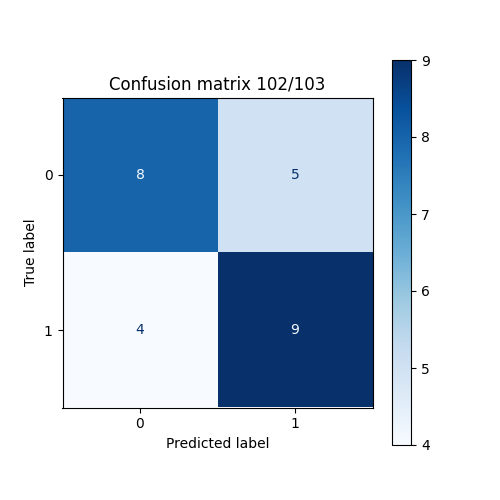

              precision    recall  f1-score   support

     Passive       0.67      0.62      0.64        13
      Active       0.64      0.69      0.67        13

    accuracy                           0.65        26
   macro avg       0.65      0.65      0.65        26
weighted avg       0.65      0.65      0.65        26



In [ ]:
# --- Confusion matrix ---
y_true = []
y_pred = []

for batch in test_dataset_102_103:
    # batch = (inputs_dict, labels)
    inputs_dict, labels = batch

    # Prédictions
    preds = multi_cam_model_0.predict(inputs_dict, verbose=0)

    # Binarisation
    preds_binary = (preds > 0.5).astype(int).flatten()

    y_pred.extend(preds_binary)
    y_true.extend(labels.numpy().astype(int).flatten())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion matrix 102/103")
plt.grid(False)
plt.savefig("/home/amerzone/kth/Confusion_Matrix_102_103.png")
plt.close()
display(Image("/home/amerzone/kth/Confusion_Matrix_102_103.png"))

# --- Classification report ---
report = classification_report(y_true, y_pred, target_names=['Passive', 'Active'])
print(report)


### Modèle 102/104 :

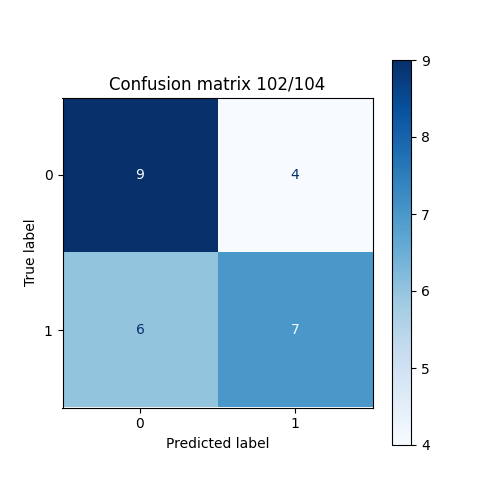

              precision    recall  f1-score   support

     Passive       0.60      0.69      0.64        13
      Active       0.64      0.54      0.58        13

    accuracy                           0.62        26
   macro avg       0.62      0.62      0.61        26
weighted avg       0.62      0.62      0.61        26



In [ ]:
# --- Confusion matrix ---
y_true = []
y_pred = []

for batch in test_dataset_102_104:
    # batch = (inputs_dict, labels)
    inputs_dict, labels = batch

    # Prédictions
    preds = multi_cam_model_1.predict(inputs_dict, verbose=0)

    # Binarisation
    preds_binary = (preds > 0.5).astype(int).flatten()

    y_pred.extend(preds_binary)
    y_true.extend(labels.numpy().astype(int).flatten())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion matrix 102/104")
plt.grid(False)
plt.savefig("/home/amerzone/kth/Confusion_Matrix_102_104.png")
plt.close()
display(Image("/home/amerzone/kth/Confusion_Matrix_102_104.png"))

# --- Classification report ---
report = classification_report(y_true, y_pred, target_names=['Passive', 'Active'])
print(report)


### Modèle 103/104 :

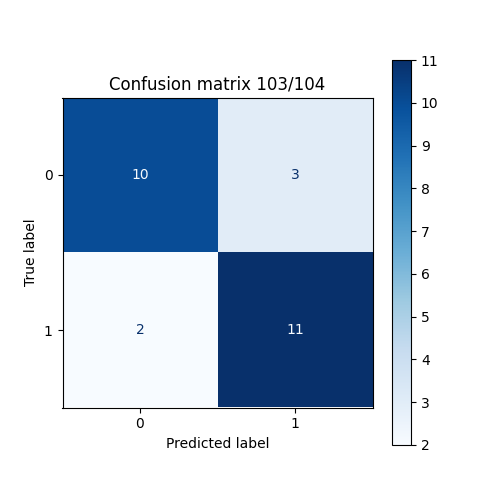

              precision    recall  f1-score   support

     Passive       0.83      0.77      0.80        13
      Active       0.79      0.85      0.81        13

    accuracy                           0.81        26
   macro avg       0.81      0.81      0.81        26
weighted avg       0.81      0.81      0.81        26



In [ ]:
# --- Confusion matrix ---
y_true = []
y_pred = []

for batch in test_dataset_103_104:
    # batch = (inputs_dict, labels)
    inputs_dict, labels = batch

    # Prédictions
    preds = multi_cam_model_2.predict(inputs_dict, verbose=0)

    # Binarisation
    preds_binary = (preds > 0.5).astype(int).flatten()

    y_pred.extend(preds_binary)
    y_true.extend(labels.numpy().astype(int).flatten())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion matrix 103/104")
plt.grid(False)
plt.savefig("/home/amerzone/kth/Confusion_Matrix_103_104.png")
plt.close()
display(Image("/home/amerzone/kth/Confusion_Matrix_103_104.png"))

# --- Classification report ---
report = classification_report(y_true, y_pred, target_names=['Passive', 'Active'])
print(report)


## Construction du modèle final

Récupération des embeddings des 3 sous-modèles

In [ ]:
embedding_model_0 = tf.keras.Model(
    inputs=multi_cam_model_0.inputs,
    outputs=multi_cam_model_0.get_layer("embedding").output
)

embedding_model_1 = tf.keras.Model(
    inputs=multi_cam_model_1.inputs,
    outputs=multi_cam_model_1.get_layer("embedding").output
)

embedding_model_2 = tf.keras.Model(
    inputs=multi_cam_model_2.inputs,
    outputs=multi_cam_model_2.get_layer("embedding").output
)

train_embeddings_102_103 = embedding_model_0.predict(
    tf.data.Dataset.from_tensor_slices(
        (train_inputs_102_103, train_labels_102_103)
    ).batch(BATCH_SIZE)
)

train_embeddings_102_104 = embedding_model_1.predict(
    tf.data.Dataset.from_tensor_slices(
        (train_inputs_102_104, train_labels_102_104)
    ).batch(BATCH_SIZE)
)

train_embeddings_103_104 = embedding_model_2.predict(
    tf.data.Dataset.from_tensor_slices(
        (train_inputs_103_104, train_labels_103_104)
    ).batch(BATCH_SIZE)
)

test_embeddings_102_103 = embedding_model_0.predict(
    tf.data.Dataset.from_tensor_slices(
        (test_inputs_102_103, test_labels_102_103)
    ).batch(BATCH_SIZE)
)

test_embeddings_102_104 = embedding_model_1.predict(
    tf.data.Dataset.from_tensor_slices(
        (test_inputs_102_104, test_labels_102_104)
    ).batch(BATCH_SIZE)
)

test_embeddings_103_104 = embedding_model_2.predict(
    tf.data.Dataset.from_tensor_slices(
        (test_inputs_103_104, test_labels_103_104)
    ).batch(BATCH_SIZE)
)

9/9 [==============================] - 0s 15ms/step


Vérification des formats et des labels (cohérence)

In [ ]:
print("[INFO] If nothing is printed everything is OK")
assert np.all(train_labels_102_103 == train_labels_102_104)
assert np.all(train_labels_102_103 == train_labels_103_104)

assert np.all(test_labels_102_103 == test_labels_102_104)
assert np.all(test_labels_102_103 == test_labels_103_104)

[INFO] If nothing is printed everything is OK


Concaténation des embeddings

In [ ]:
train_embeddings_final = np.concatenate(
    [
        train_embeddings_102_103,
        train_embeddings_102_104,
        train_embeddings_103_104
    ],
    axis=1
)

test_embeddings_final = np.concatenate(
    [
        test_embeddings_102_103,
        test_embeddings_102_104,
        test_embeddings_103_104
    ],
    axis=1
)

Construction du jeu de données final :

In [ ]:
# On construit un dataset TF pour le modèle final
train_dataset_final = (
    tf.data.Dataset.from_tensor_slices((train_embeddings_final, train_labels_102_103))
    .shuffle(512, seed=RANDOM_PARAM, reshuffle_each_iteration=False)  # garde le même ordre que pour les duos
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Même pour le jeu de test (on ne shuffle pas)
test_dataset_final = (
    tf.data.Dataset.from_tensor_slices((test_embeddings_final, test_labels_102_103))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

Création du modèle final :

In [ ]:
final_input = Input(shape=(1536,))
x = Dense(256, activation='relu')(final_input)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

final_model = tf.keras.Model(final_input, output)
final_model.summary() 

Model: "model_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1536)]            0         
                                                                 
 dense_12 (Dense)            (None, 256)               393472    
                                                                 
 dropout_9 (Dropout)         (None, 256)               0         
                                                                 
 dense_13 (Dense)            (None, 1)                 257       
                                                                 
Total params: 393,729
Trainable params: 393,729
Non-trainable params: 0
_________________________________________________________________


## Compilation et lancement du modèle final :

In [ ]:
final_model.compile(
    #optimizer=tf.keras.optimizers.RMSprop(5e-5),tf.keras.optimizers.experimental.AdamW(learning_rate=1e-4, weight_decay=1e-5),
    optimizer=tf.keras.optimizers.experimental.AdamW(learning_rate=1e-4, weight_decay=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

final_model.fit(
    train_dataset_final,
    epochs=EPOCHS_FINAL,
    validation_data=test_dataset_final,
    verbose=1,
    class_weight={0: 2.0, 1: 1.0} 
)

Epoch 1/100
33/33 [==============================] - 5s 32ms/step - loss: 0.2154 - accuracy: 0.9286 - val_loss: 0.7603 - val_accuracy: 0.6923
Epoch 2/100
33/33 [==============================] - 1s 34ms/step - loss: 0.0350 - accuracy: 0.9898 - val_loss: 0.8632 - val_accuracy: 0.7308
Epoch 3/100
33/33 [==============================] - 0s 6ms/step - loss: 0.0186 - accuracy: 1.0000 - val_loss: 0.9134 - val_accuracy: 0.7308
Epoch 4/100
33/33 [==============================] - 0s 6ms/step - loss: 0.0156 - accuracy: 1.0000 - val_loss: 0.9601 - val_accuracy: 0.7308
Epoch 5/100
33/33 [==============================] - 0s 6ms/step - loss: 0.0139 - accuracy: 1.0000 - val_loss: 0.9967 - val_accuracy: 0.7692
Epoch 6/100
33/33 [==============================] - 0s 5ms/step - loss: 0.0083 - accuracy: 1.0000 - val_loss: 1.0445 - val_accuracy: 0.7308
Epoch 7/100
33/33 [==============================] - 0s 7ms/step - loss: 0.0084 - accuracy: 1.0000 - val_loss: 1.0773 - val_accuracy: 0.7692
Epoch 8/100

## Matrice de confusion et métriques du modèle final (precision, recall, F1)

Meilleur seuil pour F1 : 0.09968568

=== Faux positifs ===
{'type': 'negative', 'session': 'Session_8', 'frame': 893, 'videos': {'192.168.1.102': {'video': 'video1_1.mp4', 'full_path': '/home/amerzone/kth/VIDEOS_NEW/Session_8/192.168.1.102/video1_1.mp4', 'frame': 893}, '192.168.1.103': {'video': 'video1_1.mp4', 'full_path': '/home/amerzone/kth/VIDEOS_NEW/Session_8/192.168.1.103/video1_1.mp4', 'frame': 893}}}
{'type': 'negative', 'session': 'Session_9', 'frame': 1067, 'videos': {'192.168.1.102': {'video': 'video1_1.mp4', 'full_path': '/home/amerzone/kth/VIDEOS_NEW/Session_9/192.168.1.102/video1_1.mp4', 'frame': 1067}, '192.168.1.103': {'video': 'video1_1.mp4', 'full_path': '/home/amerzone/kth/VIDEOS_NEW/Session_9/192.168.1.103/video1_1.mp4', 'frame': 1067}}}
{'type': 'negative', 'session': 'Session_8', 'frame': 432, 'videos': {'192.168.1.102': {'video': 'video1_1.mp4', 'full_path': '/home/amerzone/kth/VIDEOS_NEW/Session_8/192.168.1.102/video1_1.mp4', 'frame': 432}, '192.168.1.103': {'vi

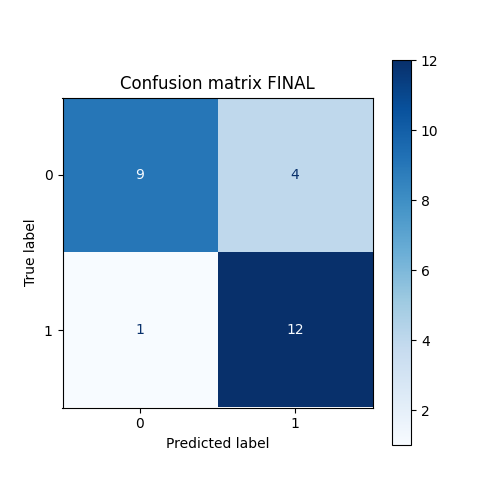

              precision    recall  f1-score   support

     Passive       0.90      0.69      0.78        13
      Active       0.75      0.92      0.83        13

    accuracy                           0.81        26
   macro avg       0.82      0.81      0.81        26
weighted avg       0.83      0.81      0.81        26



In [ ]:
# --- Confusion matrix ---
y_true = []
y_pred = []

# --- Préparer les données ---
y_true = test_labels_102_103  # labels du test
y_pred = final_model.predict(test_embeddings_final, verbose=0).flatten()  # prédictions continues

# --- Calcul du meilleur seuil F1 ---
precision, recall, thresholds = precision_recall_curve(y_true, y_pred)
f1_score = 2 * precision * recall / (precision + recall + 1e-8)
best_index = np.argmax(f1_score)
best_thres = thresholds[best_index]
print("Meilleur seuil pour F1 :", best_thres)


if best_thres>0.5 : 
    y_pred_bin = (y_pred > 0.5).astype(int)
    #y_pred_bin = (y_pred > best_thres).astype(int)
else :
    y_pred_bin = (y_pred > best_thres).astype(int)

#y_pred_bin = (y_pred > 0.5).astype(int)


# --- Identifier les erreurs ---
y_true_arr = np.array(y_true)
y_pred_arr = np.array(y_pred_bin)
#test_video_names_arr = np.array(test_video_names_final)

# Faux positifs : prédiction = 1 alors que label = 0
fp_idx = np.where((y_pred_arr == 1) & (y_true_arr == 0))[0]
# Faux négatifs : prédiction = 0 alors que label = 1
fn_idx = np.where((y_pred_arr == 0) & (y_true_arr == 1))[0]

print("\n=== Faux positifs ===")
for idx in fp_idx:
    meta = test_meta[idx]
    print(meta)

print("\n=== Faux négatifs ===")
for idx in fn_idx:
    meta = test_meta[idx]
    print(meta)


# Confusion matrix
cm = confusion_matrix(y_true, y_pred_bin)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion matrix FINAL")
plt.grid(False)
plt.savefig("/home/amerzone/kth/Confusion_Matrix_FINAL.png")
plt.close()
display(Image("/home/amerzone/kth/Confusion_Matrix_FINAL.png"))

# --- Classification report ---
report = classification_report(y_true, y_pred_bin, target_names=['Passive', 'Active'])
print(report)
